In [45]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D
from lifelines import CoxPHFitter
import warnings
warnings.filterwarnings("ignore")
from scipy.stats import zscore
from matplotlib.colors import ListedColormap

print("All packages loaded successfully.")

All packages loaded successfully.


# Preparing Data

In [46]:
# load in datasets
expr = pd.read_csv('../datasets/csv_files/penalized_cox_sig_genes_train.csv')
clinical = pd.read_csv('../datasets/csv_files/clinical_metadata_train.csv')
univariate_results = pd.read_csv('../datasets/csv_files/univariate_cox_sig_train.csv')
clinical.head()

,sample_name,is_tumor,patient_age,tumor_grade,tumor_size,er_status,lymph_node_status,relapse_free_event,relapse_free_time
0,GSM1045191,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,GSM1045192,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,GSM1045193,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,GSM1045194,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,GSM1045195,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [47]:
# load test datasets (full expression matrices  sig genes will be filtered when scoring)
test_data_one   = pd.read_csv('../datasets/csv_files/ml_datasets/test_data_one.csv').dropna(subset=['relapse_free_time', 'relapse_free_event'])
test_data_two   = pd.read_csv('../datasets/csv_files/ml_datasets/test_data_two.csv').dropna(subset=['relapse_free_time', 'relapse_free_event'])
test_data_three = pd.read_csv('../datasets/csv_files/ml_datasets/test_data_three.csv').dropna(subset=['relapse_free_time', 'relapse_free_event'])

print(f"Test 1: {len(test_data_one)} patients")
print(f"Test 2: {len(test_data_two)} patients")
print(f"Test 3: {len(test_data_three)} patients")

Test 1: 244 patients
Test 2: 88 patients
Test 3: 117 patients


In [48]:
# get just gene columns (exclude sample_name and survival columns that come along in the CSV)
survival_cols = {'sample_name', 'relapse_free_event', 'relapse_free_time'}
gene_cols = [col for col in expr.columns if col not in survival_cols]
print(f"{len(gene_cols)} gene columns: {gene_cols}")

21 gene columns: ['KLHL5', 'BLNK', 'SOX4', 'UBE2S', 'S100P', 'DEFB132', 'COLEC12', 'MICB', 'EIF4E3', 'GNS', 'ARF1', 'FBXL16', 'CFB', 'SOD2', 'TRIM45', 'MTHFD1', 'MDK', 'CEBPD', 'STAT5A', 'ACO1', 'TF']


In [49]:
# prepare train data & genes + clinical covariates (drop survival cols from expr to avoid duplicate columns)
clinical_columns = ['sample_name', 'relapse_free_event', 'relapse_free_time',
                    'tumor_size', 'er_status', 'lymph_node_status', 'tumor_grade']
expr_genes_only = expr.drop(columns=['relapse_free_event', 'relapse_free_time'], errors='ignore')

train_data = pd.merge(
    clinical[clinical_columns],
    expr_genes_only,
    on='sample_name'
)

train_data = train_data.dropna()
train_data[['relapse_free_event', 'relapse_free_time']] = train_data[['relapse_free_event', 'relapse_free_time']].astype(int)

print(f"Training patients with complete gene + clinical data: {len(train_data)}")
train_data.head()

Training patients with complete gene + clinical data: 101


,sample_name,relapse_free_event,relapse_free_time,tumor_size,er_status,lymph_node_status,tumor_grade,KLHL5,BLNK,SOX4,...,FBXL16,CFB,SOD2,TRIM45,MTHFD1,MDK,CEBPD,STAT5A,ACO1,TF
0,GSM1045208,0,3026,0.0,1.0,1.0,2.0,4.727495,8.036585,7.735311,...,5.220802,7.205254,6.141279,6.428617,7.813484,6.349483,5.476177,7.169852,4.799942,4.314603
1,GSM1045209,1,755,5.0,1.0,1.0,2.0,4.202276,6.248417,7.967062,...,5.929740,7.136334,5.582510,6.394637,7.254114,7.848696,6.687999,6.309295,4.971609,4.921310
2,GSM1045210,0,3014,3.0,1.0,0.0,1.0,4.771116,7.606303,8.076291,...,5.401792,7.301934,6.262349,6.074443,7.482227,7.003300,6.107935,6.531898,4.555494,4.437907
3,GSM1045211,1,406,1.0,1.0,1.0,3.0,3.711394,5.238047,7.511513,...,5.254027,5.207979,5.432534,5.916733,6.905146,6.749071,5.820589,6.227280,4.668031,4.252302
4,GSM1045212,0,2225,2.0,0.0,0.0,3.0,4.633546,6.438748,7.601258,...,4.999650,6.896423,6.716884,6.681431,8.217102,8.426718,6.264166,7.649678,5.458046,4.873803


# Multivariate Cox: Genes + Clinical Variables

Single model combining all penalized Cox genes with clinical covariates.
Identifies which genes remain significant after adjusting for tumor size, ER status, lymph node status, and tumor grade.

In [50]:
clinical_covariates = ['tumor_size', 'er_status', 'lymph_node_status', 'tumor_grade']
all_covariates = gene_cols + clinical_covariates

cph = CoxPHFitter()
cph.fit(
    train_data[all_covariates + ['relapse_free_time', 'relapse_free_event']],
    duration_col='relapse_free_time',
    event_col='relapse_free_event',
    formula=' + '.join(all_covariates)
)

s = cph.summary
all_results = pd.DataFrame({
    "variable":    s.index,
    "gene":        s.index,
    "beta":        s["coef"].round(4),
    "HR":          s["exp(coef)"].round(4),
    "HR_lower_95": s["exp(coef) lower 95%"].round(4),
    "HR_upper_95": s["exp(coef) upper 95%"].round(4),
    "p_value":     s["p"].round(4),
}).reset_index(drop=True).sort_values("p_value")

print("All results (sorted by p-value):")
all_results

All results (sorted by p-value):


,variable,gene,beta,HR,HR_lower_95,HR_upper_95,p_value
23,lymph_node_status,lymph_node_status,1.7819,5.9413,1.8500,19.0809,0.0028
3,UBE2S,UBE2S,0.5526,1.7377,1.0712,2.8189,0.0252
4,S100P,S100P,0.2211,1.2475,1.0230,1.5212,0.0289
21,tumor_size,tumor_size,0.3650,1.4406,1.0203,2.0339,0.0380
7,MICB,MICB,-0.3651,0.6941,0.4721,1.0206,0.0634
0,KLHL5,KLHL5,-1.0343,0.3555,0.1182,1.0692,0.0656
14,TRIM45,TRIM45,-0.7574,0.4689,0.2025,1.0856,0.0770
9,GNS,GNS,-0.8559,0.4249,0.1463,1.2336,0.1155
1,BLNK,BLNK,-0.2534,0.7761,0.5267,1.1436,0.2000
11,FBXL16,FBXL16,-0.5011,0.6058,0.2803,1.3095,0.2025


In [51]:
# Significant genes only (exclude clinical covariates from sig genes list)
sig_genes_df = all_results[
    (all_results["p_value"] < 0.05) & (all_results["gene"].isin(gene_cols))
].copy()
sig_genes_df["role"] = sig_genes_df["HR"].apply(lambda hr: "danger" if hr > 1 else "protective")

sig_genes = sig_genes_df["gene"].tolist()

print(f"{'='*55}")
print(f"Total covariates tested:      {len(all_results)}")
print(f"Significant genes (p < 0.05): {len(sig_genes)}")
print(f"{'='*55}\n")
print(sig_genes_df[["gene", "beta", "HR", "HR_lower_95", "HR_upper_95", "p_value", "role"]].to_string(index=False))

print(f"\nClinical variables:")
print(all_results[all_results["gene"].isin(clinical_covariates)][["gene", "HR", "p_value"]].to_string(index=False))

Total covariates tested:      25
Significant genes (p < 0.05): 2

 gene   beta     HR  HR_lower_95  HR_upper_95  p_value   role
UBE2S 0.5526 1.7377       1.0712       2.8189   0.0252 danger
S100P 0.2211 1.2475       1.0230       1.5212   0.0289 danger

Clinical variables:
             gene     HR  p_value
lymph_node_status 5.9413   0.0028
       tumor_size 1.4406   0.0380
      tumor_grade 0.6542   0.3265
        er_status 0.7264   0.5676


In [52]:
PAPER_SIGNATURE = ["TSLP", "BIRC5", "S100B", "MDK", "S100P", "RARRES3", "BLNK", "ACO1"]

in_paper  = [g for g in sig_genes if g in PAPER_SIGNATURE]
not_paper = [g for g in sig_genes if g not in PAPER_SIGNATURE]
missing   = [g for g in PAPER_SIGNATURE if g not in sig_genes]

print("=" * 50)
print(f"  IMMUNE RISK SIGNATURE  ({len(sig_genes)} genes)")
print("=" * 50)
for _, row in sig_genes_df.iterrows():
    marker = "  [paper]" if row["gene"] in PAPER_SIGNATURE else ""
    print(f"  {row['gene']:<12}  HR={row['HR']:.3f}  p={row['p_value']:.4f}  {row['role']}{marker}")

print()
print(f"Paper overlap : {len(in_paper)}/{len(PAPER_SIGNATURE)} genes found  {in_paper}")
print(f"Novel genes   : {not_paper}")
print(f"Paper genes missing from signature: {missing}")

  IMMUNE RISK SIGNATURE  (2 genes)
  UBE2S         HR=1.738  p=0.0252  danger
  S100P         HR=1.248  p=0.0289  danger  [paper]

Paper overlap : 1/8 genes found  ['S100P']
Novel genes   : ['UBE2S']
Paper genes missing from signature: ['TSLP', 'BIRC5', 'S100B', 'MDK', 'RARRES3', 'BLNK', 'ACO1']


Saved: multivariate_forest_plot.png


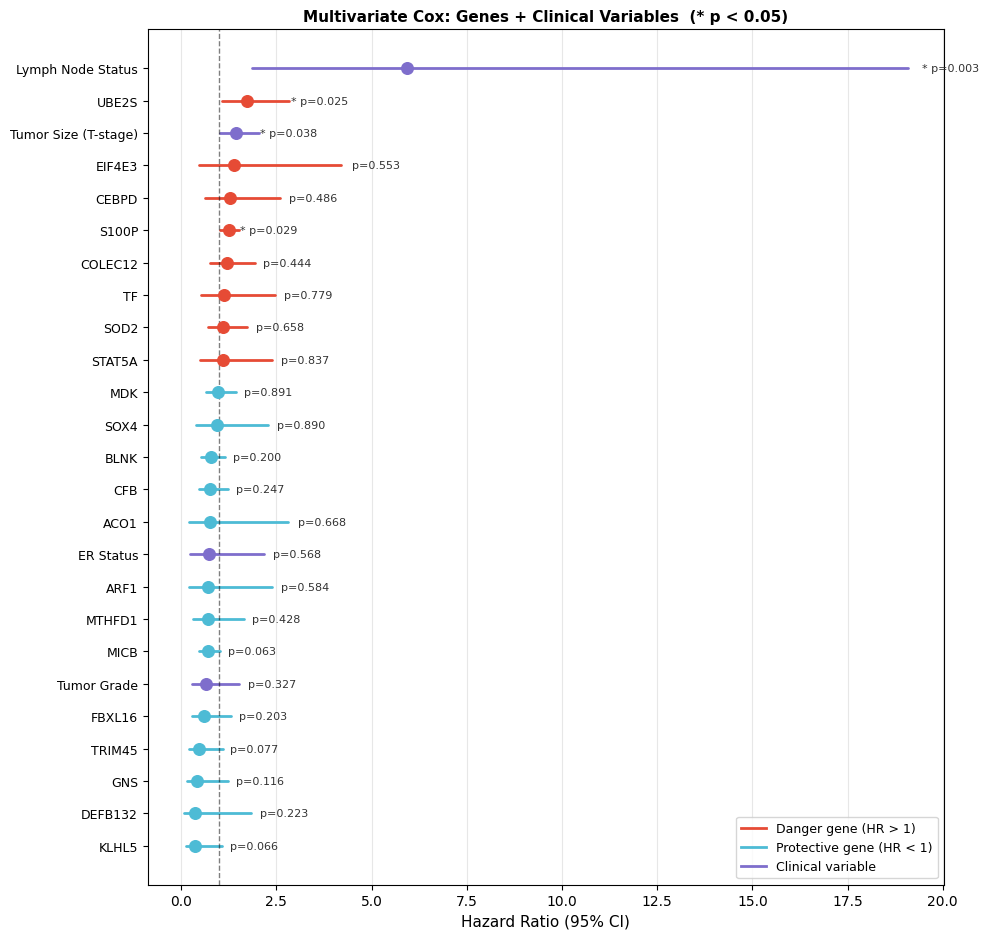

In [53]:
# Forest plot  all variables, genes highlighted by significance
label_map = {
    'tumor_size':        'Tumor Size (T-stage)',
    'er_status':         'ER Status',
    'lymph_node_status': 'Lymph Node Status',
    'tumor_grade':       'Tumor Grade',
}

plot_df = all_results.sort_values("HR").reset_index(drop=True)
plot_df["label"] = plot_df["gene"].apply(lambda g: label_map.get(g, g))

def row_color(row):
    if row["gene"] in clinical_covariates:
        return "#7E6ECC"           # purple for clinical vars
    return "#E64B35" if row["HR"] > 1 else "#4DBBD5"

colors = [row_color(row) for _, row in plot_df.iterrows()]

fig, ax = plt.subplots(figsize=(10, max(5, len(plot_df) * 0.38)))

for i, (_, row) in enumerate(plot_df.iterrows()):
    ax.plot([row["HR_lower_95"], row["HR_upper_95"]], [i, i],
            color=colors[i], linewidth=2, solid_capstyle="round")
    ax.scatter(row["HR"], i, color=colors[i], s=70, zorder=5)
    sig = "* " if row["p_value"] < 0.05 else "  "
    ax.text(row["HR_upper_95"] * 1.02, i,
            f"{sig}p={row['p_value']:.3f}", va="center", fontsize=8, color="#333333")

from matplotlib.lines import Line2D
ax.axvline(x=1, color="black", linestyle="--", linewidth=1, alpha=0.5)
ax.set_yticks(range(len(plot_df)))
ax.set_yticklabels(plot_df["label"], fontsize=9)
ax.set_xlabel("Hazard Ratio (95% CI)", fontsize=11)
ax.set_title("Multivariate Cox: Genes + Clinical Variables  (* p < 0.05)", fontsize=11, fontweight="bold")
legend_handles = [
    Line2D([0],[0], color="#E64B35", lw=2, label="Danger gene (HR > 1)"),
    Line2D([0],[0], color="#4DBBD5", lw=2, label="Protective gene (HR < 1)"),
    Line2D([0],[0], color="#7E6ECC", lw=2, label="Clinical variable"),
]
ax.legend(handles=legend_handles, fontsize=9, loc="lower right")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig("../visuals/multivariate_forest_plot.png", dpi=150, bbox_inches="tight")
print("Saved: multivariate_forest_plot.png")
plt.show()

# Compute Risk Score

In [54]:
def compute_risk_scores(df, elastic_net_results, sig_genes, time_col="RFS.time", event_col="RFS"):
    """
    Compute risk score for each patient using univariate Cox betas.
    
    Risk Score = sum(beta_i * expression_i)
    where beta_i comes from the univariate Cox model for gene_i.
    """
    # Extract betas for sig genes only, indexed by gene name
    beta_series = (
        elastic_net_results
        .loc[elastic_net_results["gene"].isin(sig_genes)]
        .set_index("gene")["beta"]
    )
    
    # Align: only genes present in both the results and the dataframe
    common_genes = [g for g in sig_genes if g in beta_series.index and g in df.columns]
    if len(common_genes) < len(sig_genes):
        missing = set(sig_genes) - set(common_genes)
        print(f"  Warning: {len(missing)} genes dropped (not in data or results): {missing}")
    
    beta_series = beta_series[common_genes]   # same order

    # Dot product: pandas aligns on index/column names automatically
    risk_scores = df[common_genes] @ beta_series  # shape: (n_patients,)

    # Include sample_name if present so downstream notebooks can align by ID
    out_cols = [c for c in ["sample_name", time_col, event_col] if c in df.columns]
    out = df[out_cols].copy()
    out["risk_score"] = risk_scores

    print(f"  Risk scores computed for {len(out)} patients using {len(common_genes)} genes")
    print(f"  Score range: {risk_scores.min():.4f} to {risk_scores.max():.4f}")
    print(f"  Score mean:  {risk_scores.mean():.4f}  std: {risk_scores.std():.4f}")

    return out

In [55]:
# Risk score = sum(beta_i * expression_i) for significant genes
# Betas come from the combined multivariate Cox (adjusted for clinical variables)
print(f"Computing risk scores using {len(sig_genes)} significant genes: {sig_genes}\n")

train_scores      = compute_risk_scores(train_data,      all_results, sig_genes, "relapse_free_time", "relapse_free_event")
test_one_scores   = compute_risk_scores(test_data_one,   all_results, sig_genes, "relapse_free_time", "relapse_free_event")
test_two_scores   = compute_risk_scores(test_data_two,   all_results, sig_genes, "relapse_free_time", "relapse_free_event")
test_three_scores = compute_risk_scores(test_data_three, all_results, sig_genes, "relapse_free_time", "relapse_free_event")

print("\nRisk score summaries:")
for name, df in [("Train",  train_scores), ("Test 1", test_one_scores),
                 ("Test 2", test_two_scores), ("Test 3", test_three_scores)]:
    s = df["risk_score"]
    print(f"  {name:8s} n={len(s):3d}  mean={s.mean():.3f}  median={s.median():.3f}  "
          f"min={s.min():.3f}  max={s.max():.3f}")

Computing risk scores using 2 significant genes: ['UBE2S', 'S100P']

  Risk scores computed for 101 patients using 2 genes
  Score range: 3.5623 to 7.4562
  Score mean:  5.0056  std: 0.7889
  Risk scores computed for 244 patients using 2 genes
  Score range: 4.5311 to 8.3659
  Score mean:  6.5262  std: 0.7924
  Risk scores computed for 88 patients using 2 genes
  Score range: 4.7899 to 8.2741
  Score mean:  6.6623  std: 0.7544
  Risk scores computed for 117 patients using 2 genes
  Score range: 5.1926 to 8.7559
  Score mean:  6.4715  std: 0.6739

Risk score summaries:
  Train    n=101  mean=5.006  median=5.032  min=3.562  max=7.456
  Test 1   n=244  mean=6.526  median=6.566  min=4.531  max=8.366
  Test 2   n= 88  mean=6.662  median=6.703  min=4.790  max=8.274
  Test 3   n=117  mean=6.471  median=6.322  min=5.193  max=8.756


# Gene Signature Visualizations

Saved: gene_signature_heatmap.png


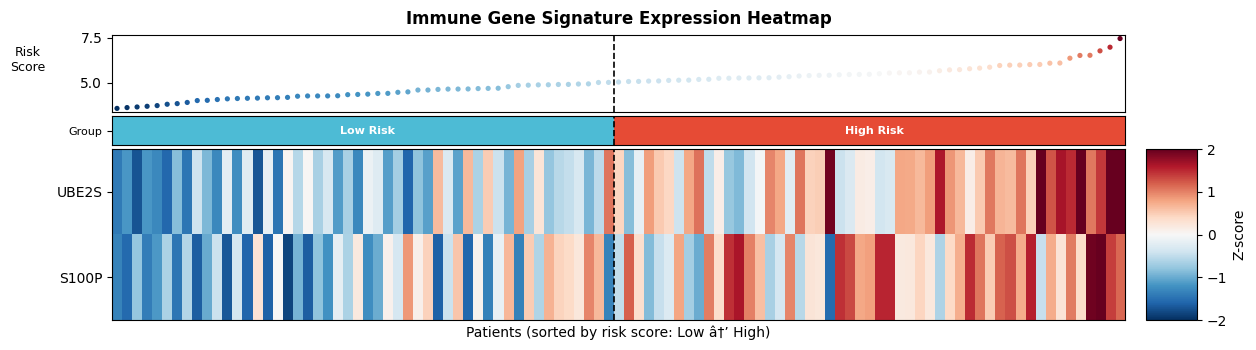

In [56]:
# Sort patients by risk score (low â†’ high) for consistent ordering across all plots
vis_median = train_scores["risk_score"].median()
vis_groups = np.where(train_scores["risk_score"].values >= vis_median, "High Risk", "Low Risk")
vis_group_series = pd.Series(vis_groups, index=train_data.index)

sort_idx      = np.argsort(train_scores["risk_score"].values)
sorted_scores = train_scores["risk_score"].values[sort_idx]
sorted_groups = vis_groups[sort_idx]

# Expression matrix: genes Ã— patients (sorted), z-scored per gene
expr_mat = train_data[sig_genes].values[sort_idx].T        # shape: (n_genes, n_patients)
expr_z   = zscore(expr_mat, axis=1)
n_patients = expr_mat.shape[1]
split = int(np.sum(sorted_groups == "Low Risk"))

# Heatmap
fig = plt.figure(figsize=(14, 2.5 + len(sig_genes) * 0.6))
gs  = fig.add_gridspec(3, 2,
                       height_ratios=[0.9, 0.35, len(sig_genes)],
                       width_ratios=[20, 1],
                       hspace=0.04, wspace=0.04)

# Risk score track
ax_rs = fig.add_subplot(gs[0, 0])
ax_rs.scatter(range(n_patients), sorted_scores,
              c=sorted_scores, cmap="RdBu_r", s=14, linewidths=0)
ax_rs.axvline(split - 0.5, color="black", lw=1.2, ls="--")
ax_rs.set_ylabel("Risk\nScore", fontsize=9, rotation=0, labelpad=38)
ax_rs.set_xlim(-0.5, n_patients - 0.5)
ax_rs.set_xticks([])
ax_rs.set_title("Immune Gene Signature Expression Heatmap", fontsize=12, fontweight="bold", pad=8)

# Group colour track
ax_grp = fig.add_subplot(gs[1, 0], sharex=ax_rs)
ax_grp.imshow(np.where(sorted_groups == "High Risk", 1, 0).reshape(1, -1),
              aspect="auto", cmap=ListedColormap(["#4DBBD5", "#E64B35"]), vmin=0, vmax=1)
ax_grp.set_yticks([0])
ax_grp.set_yticklabels(["Group"], fontsize=8)
ax_grp.set_xticks([])
ax_grp.axvline(split - 0.5, color="black", lw=1.2, ls="--")
ax_grp.text(split / 2, 0, "Low Risk",  ha="center", va="center", fontsize=8, color="white", fontweight="bold")
ax_grp.text(split + (n_patients - split) / 2, 0, "High Risk", ha="center", va="center", fontsize=8, color="white", fontweight="bold")

# Expression heatmap
ax_hm = fig.add_subplot(gs[2, 0], sharex=ax_rs)
im = ax_hm.imshow(expr_z, aspect="auto", cmap="RdBu_r", vmin=-2, vmax=2)
ax_hm.set_yticks(range(len(sig_genes)))
ax_hm.set_yticklabels(sig_genes, fontsize=10)
ax_hm.set_xlabel("Patients (sorted by risk score: Low â†’ High)", fontsize=10)
ax_hm.axvline(split - 0.5, color="black", lw=1.2, ls="--")

plt.colorbar(im, cax=fig.add_subplot(gs[2, 1]), label="Z-score")
plt.savefig("../visuals/gene_signature_heatmap.png", dpi=150, bbox_inches="tight")
print("Saved: gene_signature_heatmap.png")
plt.show()

Saved: gene_signature_expression.png


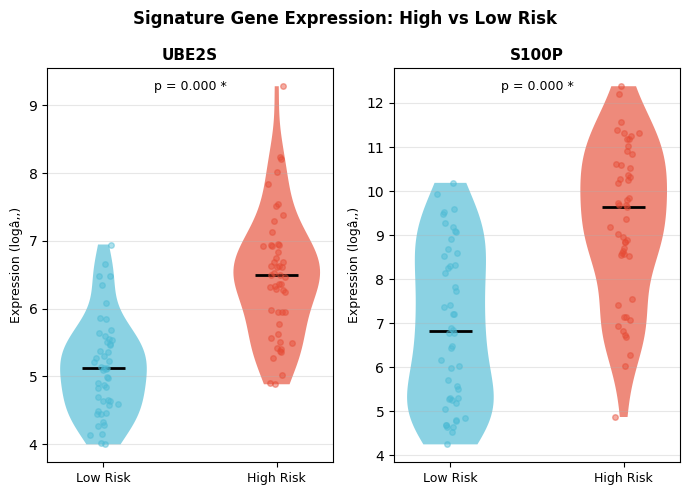

In [ ]:
from scipy.stats import mannwhitneyu

# Violin plots: expression of each sig gene in high vs low risk
n_genes = len(sig_genes)
fig, axes = plt.subplots(1, n_genes, figsize=(max(6, 3.5 * n_genes), 5))
if n_genes == 1:
    axes = [axes]

for ax, gene in zip(axes, sig_genes):
    data_low  = train_data.loc[vis_group_series == "Low Risk",  gene].values
    data_high = train_data.loc[vis_group_series == "High Risk", gene].values

    parts = ax.violinplot([data_low, data_high], positions=[0, 1],
                          showmedians=True, showextrema=False)
    for pc, color in zip(parts["bodies"], ["#4DBBD5", "#E64B35"]):
        pc.set_facecolor(color)
        pc.set_alpha(0.65)
    parts["cmedians"].set_color("black")
    parts["cmedians"].set_linewidth(2)

    # Jittered points
    for pos, data, color in [(0, data_low, "#4DBBD5"), (1, data_high, "#E64B35")]:
        jitter = np.random.default_rng(42).normal(0, 0.04, len(data))
        ax.scatter(pos + jitter, data, alpha=0.45, s=16, color=color, zorder=3)

    # Mann-Whitney U p-value
    _, p = mannwhitneyu(data_low, data_high, alternative="two-sided")
    ax.text(0.5, 0.97, f"p = {p:.3f}" + (" *" if p < 0.05 else ""),
            transform=ax.transAxes, ha="center", va="top", fontsize=9)

    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Low Risk", "High Risk"], fontsize=9)
    ax.set_title(gene, fontsize=11, fontweight="bold")
    ax.set_ylabel("Expression (logâ‚‚)", fontsize=9)
    ax.grid(axis="y", alpha=0.3)

plt.suptitle("Signature Gene Expression: High vs Low Risk", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("../visuals/gene_signature_expression.png", dpi=150, bbox_inches="tight")
print("Saved: gene_signature_expression.png")
plt.show()

Saved: gene_signature_correlation.png


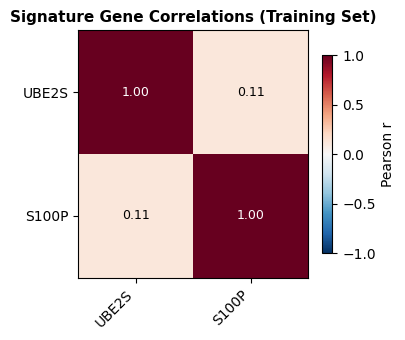

In [58]:
# Correlation heatmap between sig genes 
if len(sig_genes) > 1:
    corr = train_data[sig_genes].corr(method="pearson")

    fig, ax = plt.subplots(figsize=(max(4, len(sig_genes)), max(3.5, len(sig_genes))))
    im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")

    ax.set_xticks(range(len(sig_genes)))
    ax.set_yticks(range(len(sig_genes)))
    ax.set_xticklabels(sig_genes, rotation=45, ha="right", fontsize=10)
    ax.set_yticklabels(sig_genes, fontsize=10)

    for i in range(len(sig_genes)):
        for j in range(len(sig_genes)):
            v = corr.values[i, j]
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=9,
                    color="white" if abs(v) > 0.6 else "black")

    plt.colorbar(im, ax=ax, label="Pearson r", shrink=0.8)
    ax.set_title("Signature Gene Correlations (Training Set)", fontsize=11, fontweight="bold")
    plt.tight_layout()
    plt.savefig("../visuals/gene_signature_correlation.png", dpi=150, bbox_inches="tight")
    print("Saved: gene_signature_correlation.png")
    plt.show()
else:
    print("Only 1 significant gene  correlation heatmap skipped.")

# Patient Stratification (High vs Low Risk)

Training median risk score (cutoff): 5.0316
Train     high= 51  low= 50  log-rank p=0.0005
Test 1    high=235  low=  9  log-rank p=0.1185
Test 2    high= 86  low=  2  log-rank p=0.3125
Test 3    high=117  low=  0  log-rank p=nan

Saved: km_risk_stratification.png


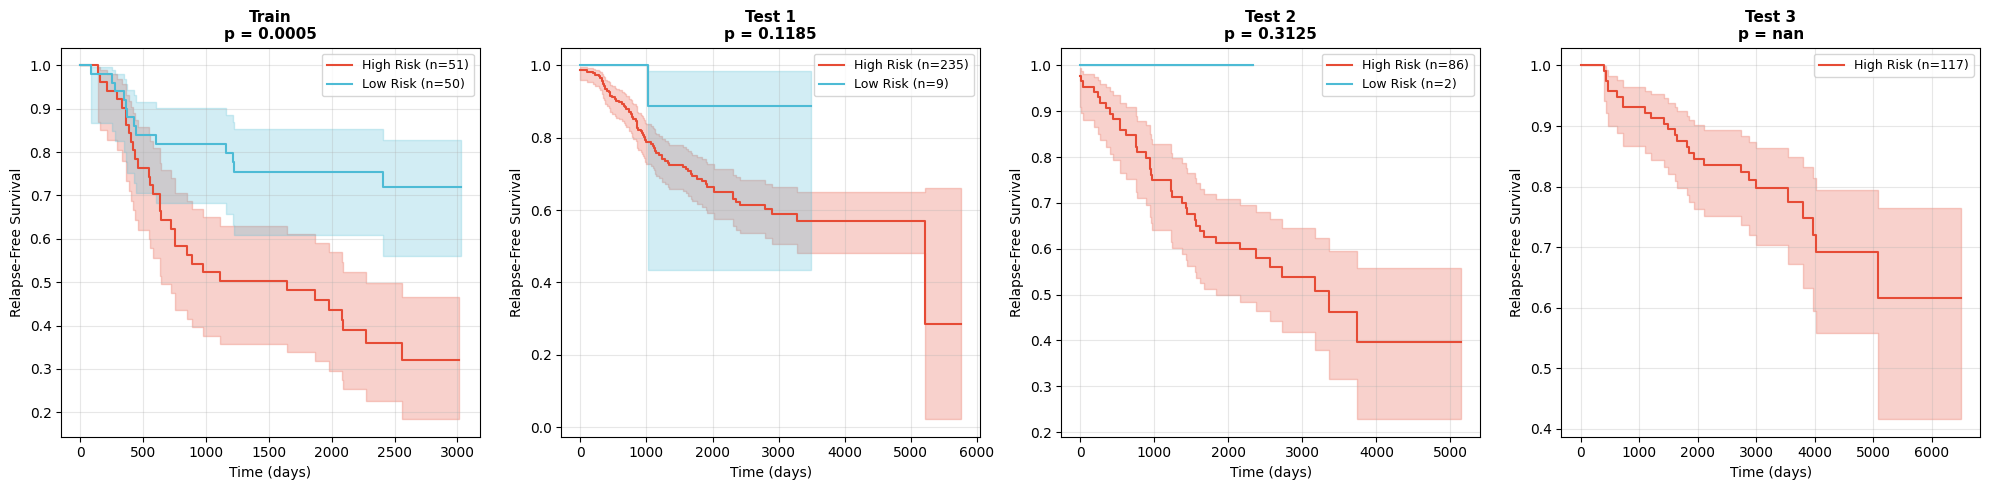

In [59]:
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test

# Cutoff: median of the training risk scores (applied consistently to all test sets)
train_median = train_scores["risk_score"].median()
print(f"Training median risk score (cutoff): {train_median:.4f}")

def stratify(scores_df):
    return np.where(scores_df["risk_score"] >= train_median, "High Risk", "Low Risk")

def plot_km(scores_df, title, ax):
    """KM curves for high vs low risk groups."""
    groups = stratify(scores_df)
    tmp = pd.DataFrame({
        "time":  pd.to_numeric(scores_df["relapse_free_time"],  errors="coerce").astype(float),
        "event": pd.to_numeric(scores_df["relapse_free_event"], errors="coerce").astype(bool),
        "group": groups,
    }).dropna(subset=["time", "event"])

    kmf = KaplanMeierFitter()
    colors = {"High Risk": "#E64B35", "Low Risk": "#4DBBD5"}

    for group, color in colors.items():
        mask = tmp["group"] == group
        if mask.sum() == 0:
            print(f"  Warning: no patients in '{group}' for {title}")
            continue
        kmf.fit(tmp.loc[mask, "time"], tmp.loc[mask, "event"],
                label=f"{group} (n={mask.sum()})")
        kmf.plot_survival_function(ax=ax, ci_show=True, color=color)

    high = tmp["group"] == "High Risk"
    low  = tmp["group"] == "Low Risk"
    result = logrank_test(tmp.loc[high, "time"], tmp.loc[low, "time"],
                          tmp.loc[high, "event"], tmp.loc[low, "event"])

    ax.set_title(f"{title}\np = {result.p_value:.4f}", fontsize=11, fontweight="bold")
    ax.set_xlabel("Time (days)")
    ax.set_ylabel("Relapse-Free Survival")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    return result.p_value


score_datasets = [
    ("Train",  train_scores),
    ("Test 1", test_one_scores),
    ("Test 2", test_two_scores),
    ("Test 3", test_three_scores),
]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, (name, scores_df) in zip(axes, score_datasets):
    groups = stratify(scores_df)
    p = plot_km(scores_df, name, ax)
    print(f"{name:8s}  high={np.sum(groups == 'High Risk'):3d}  "
          f"low={np.sum(groups == 'Low Risk'):3d}  log-rank p={p:.4f}")

plt.tight_layout()
plt.savefig("../visuals/km_risk_stratification.png", dpi=150, bbox_inches="tight")
print("\nSaved: km_risk_stratification.png")
plt.show()

In [60]:
# ============================================================================
# Save all results + risk scores + group labels to CSV
# ============================================================================
all_results.to_csv("../datasets/csv_files/multivariate_cox_all_train.csv", index=False)

if len(sig_genes_df) > 0:
    sig_genes_df.to_csv("../datasets/csv_files/multivariate_cox_sig_train.csv", index=False)

print("Saved files:")
print("  multivariate_cox_all_genes.csv     — full results for all genes")
print("  multivariate_cox_significant.csv   — significant genes only (p < 0.05)")

def save_risk_scores(scores_df, path):
    out = scores_df.copy()
    out["risk_group"] = stratify(scores_df)
    out.to_csv(path, index=False)

save_risk_scores(train_scores,      "../datasets/csv_files/risk_scores_train.csv")
save_risk_scores(test_one_scores,   "../datasets/csv_files/risk_scores_test_one.csv")
save_risk_scores(test_two_scores,   "../datasets/csv_files/risk_scores_test_two.csv")
save_risk_scores(test_three_scores, "../datasets/csv_files/risk_scores_test_three.csv")

print("Saved risk score CSVs for train and all test sets.")

Saved files:
  multivariate_cox_all_genes.csv     — full results for all genes
  multivariate_cox_significant.csv   — significant genes only (p < 0.05)
Saved risk score CSVs for train and all test sets.
